In [120]:
# changes implemented:
# instead of picking two pairs of stocks we think are similar, we screen a large number of stocks, which pick for us.
# instead of doing a ratio / difference for the spread, we use hedge ratio - ols regression

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams["figure.figsize"] = (12, 5) # set default size for plots

from utils import compute_zscore, generate_signals, backtest, sharpe_ratio



In [121]:
# make wider universe of stock pairs
# group them by sector - more likely to be similar

UNIVERSE = {
    "beverages": ["KO", "PEP","BUD", "DEO", "STZ", "MNST", "KDP", "TAP", "SAM", "BF-B" ],
    "oil_majors": ["XOM", "CVX", "SHEL", "TTE", "BP", "COP", "OXY", "SLB", "EOG", "VLO"],
    "airlines": ["DAL", "UAL", "AAL", "LUV", "ALK", "JBLU", "RYAAY", "CPA", "SKYW", "DLAKY"],
    "banks": ["JPM", "BAC", "WFC", "C", "GS", "MS", "USB", "PNC", "TFC", "HSBC"],
    "casino_and_gaming": ["LVS", "MGM", "WYNN", "CZR", "DKNG", "PENN", "BYD", "RSI"],
    "chips": ["NVDA", "TSM", "AVGO", "AMD", "INTC", "QCOM", "TXN", "MU", "AMAT", "ASML"],
    "drone_unmanned": ["AVAV", "KTOS", "RCAT", "EH", "ONDS", "TXT", "JOBY", "LMT", "NOC", "BA"]
}

START_DATE = "2022-07-01"
END_DATE = "2024-01-01"

all_tickers = [t for tickers in UNIVERSE.values() for t in tickers] # 
raw_data = yf.download(all_tickers, start = START_DATE, end = END_DATE, auto_adjust=True)["Close"]
raw_data = raw_data.dropna()
raw_data.head()

[*********************100%***********************]  68 of 68 completed


Ticker,AAL,ALK,AMAT,AMD,ASML,AVAV,AVGO,BA,BAC,BF-B,...,TSM,TTE,TXN,TXT,UAL,USB,VLO,WFC,WYNN,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-07-01,13.13,41.169998,83.260445,73.669998,433.242004,85.910004,44.767174,139.839996,28.357687,65.163559,...,72.288795,42.501011,131.462982,60.862923,36.439999,38.745487,95.521889,35.832951,56.141949,76.058449
2022-07-05,13.88,41.540001,82.999878,75.199997,416.454742,83.080002,44.622887,137.699997,28.070158,64.462463,...,71.453255,41.149479,131.958618,59.329155,36.970001,38.637375,91.638390,35.994534,55.765614,73.678085
2022-07-06,13.89,41.070000,83.540314,75.349998,413.064484,83.070000,45.214062,136.309998,27.836538,64.098297,...,70.936897,39.468102,133.472031,60.016361,36.660000,38.670643,89.975288,35.455959,53.883923,72.348915
2022-07-07,14.10,40.970001,87.584152,79.300003,435.235657,85.540001,46.706486,139.970001,28.627253,64.125595,...,75.715462,40.449574,136.905930,61.380821,36.689999,38.886868,94.071114,36.012482,55.833160,74.659760
2022-07-08,13.97,40.889999,88.008812,79.349998,436.246948,82.809998,46.720528,139.070007,28.564356,63.879768,...,76.522873,40.328896,137.649353,60.813126,36.470001,38.695602,94.681519,36.066349,54.482201,74.781395


In [122]:
# generate the candidate pairs

from itertools import combinations

def generate_candidate_pairs(UNIVERSE: dict) -> list:
    all_pairs = []
    for sector, tickers in UNIVERSE.items():
        sector_pairs = list(combinations(tickers, 2))
        all_pairs.extend(sector_pairs)
    return all_pairs

candidate_pairs = generate_candidate_pairs(UNIVERSE)
print(f"{len(candidate_pairs)} candidate pairs generated")

298 candidate pairs generated


In [123]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

# engle-granger cointegration testing with the generated pairs


def cointegration_test(series_a: pd.Series, series_b: pd.Series) -> tuple:
    test_statistic, p_value, crit_values = coint(series_a, series_b)
    return test_statistic, p_value

# now screen all universe pairs

def screen_pairs(pairs: list, prices: pd.DataFrame):
    # build a list of dicts, convert to dataframe, then sort values
    results = []
 
    for ticker_a, ticker_b in pairs:
        pairs_data = prices[[ticker_a, ticker_b]].dropna()

        series_a = pairs_data[ticker_a]
        series_b = pairs_data[ticker_b]

        test_statistics, p_value = cointegration_test(series_a, series_b)

        results.append({
            "ticker_a": ticker_a,
            "ticker_b": ticker_b,
            "test_statistics": test_statistics, 
            "p_value": p_value
        })

        # convert to dataframe
    df_results = pd.DataFrame(results)

        # sort
    df_results = df_results.sort_values(by="p_value", ascending=True).reset_index(drop=True)

    return df_results

screening_results = screen_pairs(candidate_pairs, raw_data)

significance_threshold = 0.05
significant_pairs = screening_results[screening_results["p_value"] < significance_threshold]

print(f"{len(significant_pairs)} of {len(screening_results)} candidate pairs pass at p < {significance_threshold}")
print(significant_pairs)
    

8 of 298 candidate pairs pass at p < 0.05
  ticker_a ticker_b  test_statistics   p_value
0      COP      EOG        -4.024985  0.006614
1      SAM     BF-B        -3.915018  0.009456
2      BAC      PNC        -3.895709  0.010055
3     INTC       MU        -3.655177  0.020902
4     NVDA     AMAT        -3.494998  0.032841
5     AVAV     KTOS        -3.485914  0.033665
6      OXY      SLB        -3.373768  0.045349
7      ALK     JBLU        -3.360213  0.046966


Hedge ratio (beta): 0.7542
Intercept (alpha): 300.5636


<Axes: title={'center': 'OLS-residual spread (SAM ~ BF-B)'}, xlabel='Date'>

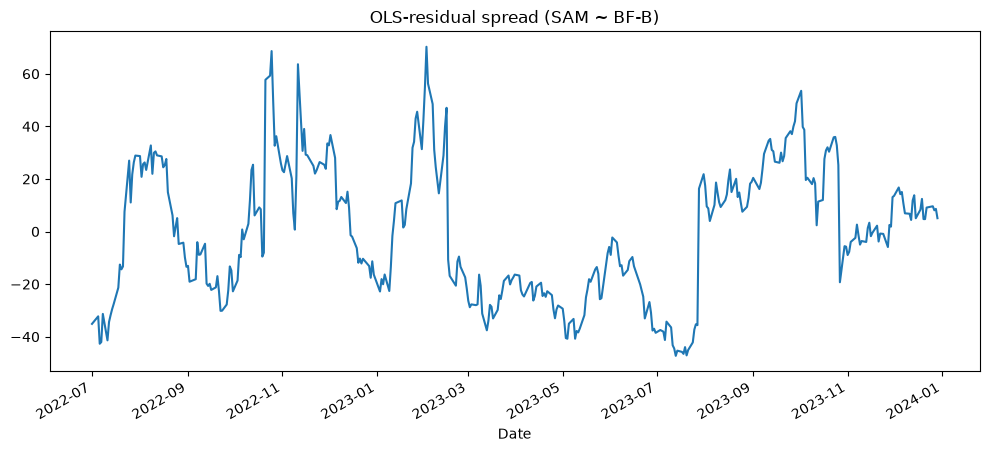

In [124]:
TICKER_A = "SAM"
TICKER_B = "BF-B"
df = raw_data[[TICKER_A, TICKER_B]].dropna()

SERIES_A = df[TICKER_A]
SERIES_B = df[TICKER_B]

# estimate ols hedge ratio
# ols regression simple formula is series_a = alpha + beta * series_b + residual
# beta is the hedge ratio, residual is the spread

def estimate_hedge_ratio(SERIES_A: pd.Series, SERIES_B: pd.Series) -> tuple:
    model = sm.OLS(SERIES_A, sm.add_constant(SERIES_B)).fit()
    alpha = model.params.iloc[0]
    beta = model.params.iloc[1]
    spread = model.resid
    return alpha, beta, spread

alpha, beta, spread = estimate_hedge_ratio(SERIES_A, SERIES_B)
print(f"Hedge ratio (beta): {beta:.4f}")
print(f"Intercept (alpha): {alpha:.4f}")
spread.plot(title=f"OLS-residual spread ({TICKER_A} ~ {TICKER_B})")

In [125]:
z_score = compute_zscore(spread, window = 30)
positions = generate_signals(z_score, entry_threshold=2.0, exit_threshold=0.5)
daily_pnl = backtest(spread, positions)
cumulative_pnl = daily_pnl.cumsum()

sr = sharpe_ratio(daily_pnl.dropna())
print(f"Cointegration-based Sharpe ({TICKER_A}/{TICKER_B}): {sr:.2f}")
print(f"Total P&L (spread units): {cumulative_pnl.iloc[-1]:.2f}")
print(f"Number of trades: {(positions.diff() != 0).sum()}")

Cointegration-based Sharpe (SAM/BF-B): 1.23
Total P&L (spread units): 160.14
Number of trades: 21
